In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

Xtrain = pd.read_csv('/dcs/22/u2243582/cs310/Xtrainfeatnew.csv', index_col=0)
ytrain = pd.read_csv('/dcs/22/u2243582/cs310/ytrain.csv', index_col=0)
Xtest = pd.read_csv('/dcs/22/u2243582/cs310/Xtestfeatnew.csv', index_col=0)
ytest = pd.read_csv('/dcs/22/u2243582/cs310/ytest.csv', index_col=0)

X = pd.concat([Xtrain, Xtest])
y = pd.concat([ytrain, ytest])
y = y.values.ravel() # array instead of 1 column

/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

pca = PCA(0.80) # keep 80% of the variance of the data
pca.fit(X)
Xtrain = pca.transform(X)

print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

Components: 6 Total explained variance: 0.8485759168090902


### XGBoost

In [5]:
cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []


for train_ix, test_ix in cv_outer.split(X): # outer CV

    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = XGBRegressor(random_state=1)

    space = {
        'max_depth': [3, 6, 9, 15],
        'learning_rate': [0.1, 0.3, 0.5, 0.7, 0.9],
        'colsample_bytree': [0.5, 1],  
        'gamma': [0, 0.5, 1, 10],   
        'reg_alpha': [0, 0.5, 1, 10],
        'reg_lambda': [1, 0.5, 10],
        'subsample': [0.1, 0.5, 0.7, 1]
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain

{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 1, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 1}
{'subsample': 1, 'reg_lambda': 10, 'reg_alpha': 0.5, 'max_depth': 6, 'learning_rate': 0.3, 'gamma': 0, 'colsample_bytree': 1}
{'subsample': 1, 'reg_lambda': 10, 'reg_alpha': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1}
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.5, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 1}
{'subsample': 1, 'reg_lambda': 0.5, 'reg_alpha': 1, 'max_depth': 9, 'learning_rate': 0.3, 'gamma': 1, 'colsample_bytree': 0.5}
Pearson Correlation: Mean = 0.7505144982709779, Std = 0.019666140896850957
Pearson P-value: Mean = 1.343378799119365e-168, Std = 0.0
Spearman Correlation: Mean = 0.7395633038334981, Std = 0.022918570737763544
Spearman P-value: Mean = 4.3261576745768364e-162, Std = 8.316801694027249e-162
Mean Absolute Error: Mean = 0.985024921885198, Std = 0.03251388276862549
Variance

In [6]:
print(pearsonCoeffs)
print(spearmanCoeffs)
print(maeScores)
print(varianceScores)
print(r2Scores)

[0.7281865449109053, 0.7433383400381471, 0.7801705065503007, 0.7663171578213593, 0.7345599420341771]
[0.7205419765848571, 0.7259909230146568, 0.7766620288603836, 0.7559363292306428, 0.7186852614769502]
[1.0298941344140546, 1.0020527299967679, 0.9343005947821696, 0.9662628686663662, 0.9926142815666312]
[1.8606005607088794, 1.6935726210179638, 1.4779847548200455, 1.6317404157396858, 1.6591847726735285]
[0.5296249530984075, 0.5448269544902238, 0.6071339416250392, 0.5871335983321011, 0.537747755447705]


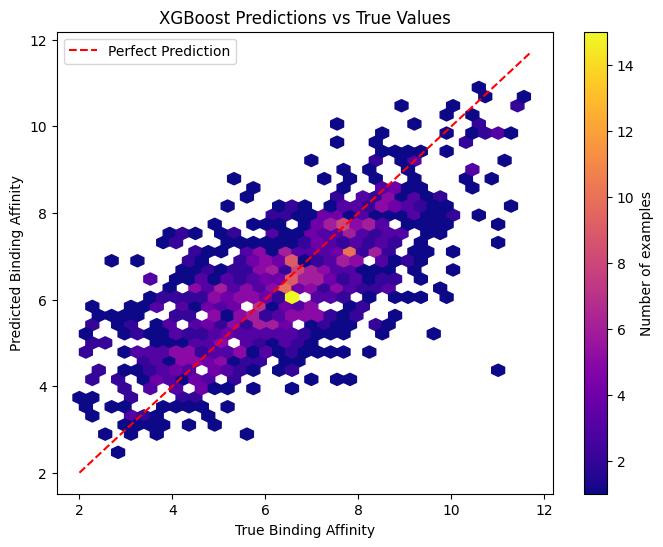

In [7]:
# Plot hexbin of true vs. predicted values
import matplotlib.pyplot as plt


# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("XGBoost Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()